# ***Google Ads Campaign Performance & Sales Analytics Using Python***

Ajay Divakar K :
DA50

### Problem statement

The purpose of this project is to analyze Google Ads campaign data to understand advertising performance, identify which campaigns generate more clicks, leads, conversions, and sales, and study the relationship between advertising cost and revenue. The project also focuses on cleaning messy real-world data and presenting useful business insights through visualizations.

### Project Objectives

The main objective is to analyze Google Ads data and understand campaign performance using impressions, clicks, leads, conversions, advertising cost, and sales. I also calculated marketing KPIs such as CTR, CPC, CPL, CPA, and ROAS.

### Phases Of Project

1. Import libraries
2. Upload and read dataset
3. Understand the dataset
4. Find missing values and duplicates
5. Clean the data
6. Convert data types
7. Handling Missing Numerical Values
8. Perform EDA
9. Create new KPI columns
10. Statistical analysis
11. Data visualizations
12. Business insights
13. Conclusion



### 1. Import libraries

in this Project we mainly focus to use below mentioned libraries

A) "Pandas" : used to work with tables and datasets.

B) "Numpy" : used for numerical calculations.

C) "Matplotlib" : used for charts and visualizations.

D) "seaborn" : Used for better statistical charts.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Upload and read dataset

Uploading the dataset collected for the project titled "Google Ads Campaign Performance & Sales Analytics Using Python" from the drive and loading it for analysis.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving GoogleAds_DataAnalytics_Sales_Uncleaned.csv to GoogleAds_DataAnalytics_Sales_Uncleaned.csv


In [ ]:
df = pd.read_csv ("GoogleAds_DataAnalytics_Sales_Uncleaned.csv")

### 3. Understand the dataset

Let's start by getting familiar with the dataset. We'll look at the first 5 rows, the last 5 rows, its size (shape), column names, and some basic information to understand how the data is organized

In [ ]:
df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,$231.88,14.0,7.0,0.058,$1892,16-11-2024,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,$216.84,10.0,8.0,0.046,$1679,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,$203.66,26.0,9.0,NaN,$1624,16-11-2024,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,$237.66,17.0,6.0,NaN,$1225,26-11-2024,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,$195.9,30.0,8.0,NaN,$1091,22-11-2024,hyderabad,desktop,online data analytic


In [ ]:
df.tail()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
2595,A3595,DataAnalyticsCourse,88.0,5344.0,$242.07,17.0,9.0,0.054,$1418,29-11-2024,HYDERABAD,MOBILE,online data analytic
2596,A3596,DataAnalyticsCourse,154.0,3211.0,$248.28,14.0,6.0,0.039,$1950,28-11-2024,hyderabad,TABLET,data analitics online
2597,A3597,Data Anlytics Corse,113.0,3808.0,$233.25,18.0,4.0,0.035,$1085,02-11-2024,Hyderbad,desktop,data anaytics training
2598,A3598,Data Analytics Corse,196.0,5853.0,$220.13,16.0,7.0,0.036,$1558,08-11-2024,hydrebad,Tablet,data anaytics training
2599,A3599,Data Analytics Corse,NaN,5453.0,NaN,12.0,5.0,NaN,$1174,22-11-2024,HYDERABAD,desktop,analytics for data


In [ ]:
df.shape

(2600, 13)

Note : could see data set have 2600 rows and 13 columns

In [ ]:
df.columns

Index(['Ad_ID', 'Campaign_Name', 'Clicks', 'Impressions', 'Cost', 'Leads',
       'Conversions', 'Conversion Rate', 'Sale_Amount', 'Ad_Date', 'Location',
       'Device', 'Keyword'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ad_ID            2600 non-null   object 
 1   Campaign_Name    2600 non-null   object 
 2   Clicks           2488 non-null   float64
 3   Impressions      2546 non-null   float64
 4   Cost             2503 non-null   object 
 5   Leads            2552 non-null   float64
 6   Conversions      2526 non-null   float64
 7   Conversion Rate  1974 non-null   float64
 8   Sale_Amount      2461 non-null   object 
 9   Ad_Date          2600 non-null   object 
 10  Location         2600 non-null   object 
 11  Device           2600 non-null   object 
 12  Keyword          2600 non-null   object 
dtypes: float64(5), object(8)
memory usage: 264.2+ KB


In [ ]:
df.dtypes

,0
Ad_ID,object
Campaign_Name,object
Clicks,float64
Impressions,float64
Cost,object
Leads,float64
Conversions,float64
Conversion Rate,float64
Sale_Amount,object
Ad_Date,object


Note : We noticed that Cost and Sale Amount are stored as text instead of numbers, and Ad Date is stored as text instead of a date format. We'll fix these data type issues during cleaning.

### 4. Find missing values and duplicates

Here, we check the dataset for any missing or duplicate values using the isnull() and duplicated() functions. This helps ensure the data is clean and ready for analysis.

In [ ]:
df.isnull().sum()

,0
Ad_ID,0
Campaign_Name,0
Clicks,112
Impressions,54
Cost,97
Leads,48
Conversions,74
Conversion Rate,626
Sale_Amount,139
Ad_Date,0


Note : Able to find out 7 out of 13 columns have missing values

In [ ]:
df.duplicated().sum()

np.int64(0)

Note : The dataset was checked for duplicate records using duplicated().sum(). No complete duplicate records were identified.

### 5. Clean the data

This dataset contains some intentional spelling mistakes and inconsistencies. In this step, we clean and correct them to make the data more accurate and consistent for analysis.

In [ ]:
# Clean the Campaign Name

df["Campaign_Name"].value_counts()

,count
Campaign_Name,
Data Analytcis Course,680
Data Analytics Corse,647
DataAnalyticsCourse,637
Data Anlytics Corse,636


In [ ]:
df["Campaign_Name"] = "Data Analytics Course"
df["Campaign_Name"].value_counts()

,count
Campaign_Name,
Data Analytics Course,2600


Note : While checking the Campaign Name column, we found several spelling mistakes. Along with the correct name, "Data Analytics Course", there were three other incorrectly spelled versions. We corrected all of them and standardized the values. Now, all campaign names in the dataset are consistent and correctly labeled as "Data Analytics Course".

In [ ]:
# Clean Location

df["Location"].value_counts()

,count
Location,
HYDERABAD,661
Hyderbad,656
hyderabad,650
hydrebad,633


In [ ]:
df["Location"] = "Hyderabad"
df["Location"].value_counts()

,count
Location,
Hyderabad,2600


Note : While reviewing the Location column, we found several variations and spelling mistakes for "Hyderabad", such as "HYDERABAD", "Hyderbad", "hyderabad", and "hydrebad". We corrected and standardized all of these values to "Hyderabad". As a result, the location data is now consistent throughout the dataset.

In [ ]:
# Clean Device Names

df["Device"].value_counts()

,count
Device,
MOBILE,311
desktop,305
Desktop,305
tablet,305
Mobile,291
TABLET,279
DESKTOP,278
mobile,276
Tablet,250


In [ ]:
df["Device"] = df["Device"].str.title()
df["Device"].value_counts()

,count
Device,
Desktop,888
Mobile,878
Tablet,834


Note : We found that some values used different letter cases (uppercase and lowercase). We standardized them so that all values follow the same format throughout the dataset.

In [ ]:
# Cleaning the Keyword column

df["Keyword"].value_counts()

,count
Keyword,
online data analytic,453
learn data analytics,444
data analytics course,440
analytics for data,429
data analitics online,420
data anaytics training,414


In [ ]:
keyword_corrections = {
    "data analitics online": "data analytics online",
    "data anaytics training": "data analytics training",
    "online data analytic": "online data analytics"
}
df["Keyword"] = df["Keyword"].replace(keyword_corrections)

In [ ]:
df["Keyword"].value_counts()

,count
Keyword,
online data analytics,453
learn data analytics,444
data analytics course,440
analytics for data,429
data analytics online,420
data analytics training,414


Note: Several Keywords contain Spelling Error, which replaced with correct spelling.

### 6. Convert data types

While reviewing the dataset, we found that the Cost, Sales Amount, and Ad Date columns had incorrect data types. We corrected them by converting each column to the proper format for accurate analysis.

In [ ]:
# Clean Cost

""" in cost could see Dollar Sign, due to that its data type shown as Text"""

df["Cost"].head()

,Cost
0,$231.88
1,$216.84
2,$203.66
3,$237.66
4,$195.9


In [ ]:
df["Cost"] = df["Cost"].str.replace("$", "", regex=False)

Note:This line of code removes the dollar sign ($) from all entries in the "Cost" column so the values can be treated as numbers instead of text (strings).

In [ ]:
df["Cost"] = pd.to_numeric(df["Cost"], errors="coerce")

Note: This line converts the "Cost" column into numbers (floats or integers), while automatically turning any invalid or unconvertible text into missing values (NaN).

In [ ]:
df["Cost"].head()

,Cost
0,231.88
1,216.84
2,203.66
3,237.66
4,195.90


In [ ]:
df["Cost"].dtype

dtype('float64')

In [ ]:
# Clean Sale Amount

df["Sale_Amount"].head()

,Sale_Amount
0,$1892
1,$1679
2,$1624
3,$1225
4,$1091


In [ ]:
df["Sale_Amount"] = df["Sale_Amount"].str.replace("$", "", regex=False)

Note: This line of code removes the dollar sign ($) from all entries in the "Sales Amount" column so the values can be treated as numbers instead of text (strings).

In [ ]:
df["Sale_Amount"] = pd.to_numeric(df["Sale_Amount"],errors="coerce")

Note: This line converts the "Sales Amount" column into numbers (floats or integers), while automatically turning any invalid or unconvertible text into missing values (NaN).

In [ ]:
df["Sale_Amount"].head()

,Sale_Amount
0,1892.0
1,1679.0
2,1624.0
3,1225.0
4,1091.0


In [ ]:
df["Sale_Amount"].dtype

dtype('float64')

In [ ]:
# Convert Ad Date

df["Ad_Date"].head()

,Ad_Date
0,16-11-2024
1,20-11-2024
2,16-11-2024
3,26-11-2024
4,22-11-2024


In [ ]:
df["Ad_Date"] = pd.to_datetime(df["Ad_Date"],format="%d-%m-%Y")

Note: This line converts the "Ad_Date" column into standard Python datetime objects, specifically telling Pandas that your raw date text is written as Day-Month-Year.

In [ ]:
df["Ad_Date"].head()

,Ad_Date
0,2024-11-16
1,2024-11-20
2,2024-11-16
3,2024-11-26
4,2024-11-22


### 7. Handle Missing Numerical Values

We used the median for the numeric columns because it is not heavily influenced by very high or very low values. This helps make the data more balanced and accurate

In [ ]:
numeric_columns = [
    "Clicks",
    "Impressions",
    "Cost",
    "Leads",
    "Conversions",
    "Sale_Amount"
]

In [ ]:
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

Note : First, we selected the numeric columns and saved them in numeric_columns. Then, we used fillna() to fill any missing values with the median of each column, helping keep the data accurate and balanced.

In [ ]:
df.isnull().sum()

,0
Ad_ID,0
Campaign_Name,0
Clicks,0
Impressions,0
Cost,0
Leads,0
Conversions,0
Conversion Rate,626
Sale_Amount,0
Ad_Date,0


7. B) Calculate Conversion Rate Properly

We calculated the missing Conversion Rate values using the formula Conversions / Clicks. This allowed us to fill the missing entries accurately using the available data.

In [ ]:
df["Conversion Rate"] = df["Conversions"] / df["Clicks"]

In [ ]:
df[["Clicks", "Conversions", "Conversion Rate"]].head()

,Clicks,Conversions,Conversion Rate
0,104.0,7.0,0.067308
1,173.0,8.0,0.046243
2,90.0,9.0,0.100000
3,142.0,6.0,0.042254
4,156.0,8.0,0.051282


In [ ]:
df["Conversion_Rate_Percent"] = (df["Conversions"] / df["Clicks"]) * 100

Note: This line converts "Conversion Rate"column into percentage under " Conversion Rate Percent"

In [ ]:
df.isnull().sum()

,0
Ad_ID,0
Campaign_Name,0
Clicks,0
Impressions,0
Cost,0
Leads,0
Conversions,0
Conversion Rate,0
Sale_Amount,0
Ad_Date,0


Note :  All Null Values were Cleared using appropriate measures.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Ad_ID                    2600 non-null   object        
 1   Campaign_Name            2600 non-null   object        
 2   Clicks                   2600 non-null   float64       
 3   Impressions              2600 non-null   float64       
 4   Cost                     2600 non-null   float64       
 5   Leads                    2600 non-null   float64       
 6   Conversions              2600 non-null   float64       
 7   Conversion Rate          2600 non-null   float64       
 8   Sale_Amount              2600 non-null   float64       
 9   Ad_Date                  2600 non-null   datetime64[ns]
 10  Location                 2600 non-null   object        
 11  Device                   2600 non-null   object        
 12  Keyword                  2600 non-

Note : After cleaning the dataset, we filled missing numeric values using the median. We also removed currency symbols from the Cost and Sale Amount columns, standardized inconsistent categorical values, and converted the Ad Date column to the correct datetime format. This made the dataset clean, consistent, and ready for analysis.

### 8. Perform EDA

Exploratory Data Analysis (EDA): its the process of analyzing, visualizing, and summarizing datasets to understand the data.

8. 1) Statistical Summary

Use df.describe() to pull up the high-level stats—giving you a fast breakdown of averages, ranges, and totals."

In [ ]:
df.describe()

,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Conversion_Rate_Percent
count,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600,2600.000000
mean,138.958846,4523.181538,215.108508,20.003846,6.532692,0.050147,1498.987692,2024-11-15 16:54:38.769230848,5.014705
min,80.000000,3000.000000,180.010000,10.000000,3.000000,0.015075,1000.000000,2024-11-01 00:00:00,1.507538
25%,111.000000,3778.000000,198.385000,15.000000,5.000000,0.032949,1262.000000,2024-11-08 00:00:00,3.294896
50%,139.000000,4518.500000,215.570000,20.000000,7.000000,0.046980,1505.000000,2024-11-16 00:00:00,4.697987
75%,167.000000,5268.250000,232.297500,25.000000,8.000000,0.063694,1728.000000,2024-11-23 00:00:00,6.369427
max,199.000000,5999.000000,249.890000,30.000000,10.000000,0.125000,2000.000000,2024-11-30 00:00:00,12.500000
std,33.865228,860.843403,19.907580,5.976353,2.241415,0.022199,279.327209,NaN,2.219905


Observation: To get a feel for the dataset, we generated a statistical summary showing key metrics like the count, average, minimum, maximum, and standard deviation for each column. This gives us a quick view of how our data behaves before moving into the analysis.

8. 2. Check Categorical Columns

Note: checking unique values and categories is a key part of the process.

In [ ]:
# checking unique values

df["Device"].unique()

array(['Desktop', 'Mobile', 'Tablet'], dtype=object)

In [ ]:
df["Keyword"].unique()

array(['learn data analytics', 'data analytics course',
       'data analytics online', 'data analytics training',
       'online data analytics', 'analytics for data'], dtype=object)

In [ ]:
df["Location"].unique()

array(['Hyderabad'], dtype=object)

In [ ]:
df["Campaign_Name"].unique()

array(['Data Analytics Course'], dtype=object)

In [ ]:
# Checking Number of unique values

df["Device"].nunique()

3

In [ ]:
df["Keyword"].nunique()

6

Observation : Before moving into charts and visuals, checked our categorical features to see what categories we were working with and counted how many unique values each column had. This helped us understand how the data is grouped and ensured everything was clean before building our visualizations.

### 9. Create new KPI columns

Key Performance Indicators (KPIs) are critical because they turn vague goals into measurable actions. Without KPIs, running a project or a business is like driving with your eyes closed—you know you're moving, but you don't know if you're heading toward a destination or off a cliff.

In [ ]:
# CTR : Click Through rate

""" It tells us how many People Clicked after seeing the advertisement"""
""" Click/Impressions * 100 """

df["CTR"] = (df["Clicks"] / df["Impressions"]) * 100

In [ ]:
# CPC : Cost Per Click

""" It tells us how much advertising money was spent for each click"""
""" Cost / Clicks """

df["CPC"] = df["Cost"] / df["Clicks"]

In [ ]:
# CPL : Cost Per Lead

""" It tells us how much advertising money was spent for each lead"""
""" Cost / Leads """

df["CPL"] = df["Cost"] / df["Leads"]

In [ ]:
# CPA : Cost per Conversion

""" It tells us how much advertising money was spent for each conversion"""
""" Cost / Conversions """

df["CPA"] = df["Cost"] / df["Conversions"]

In [ ]:
# ROAS : Return on AD Spend

""" It tells us how much money spend on Advertising and how much returns for that """
""" For every 1 spent on advertising, approximately how much in sales was generated."""
""" Sales Amount / Cost """
df["ROAS"] = df["Sale_Amount"] / df["Cost"]

Note : We checked our data, made our main metrics, and added new columns with new information. then we moving into calculating totals and other measures for creating visualization

9. SUB. Creating Overall Business Metrics

We're adding up the total for each column and putting the numbers under a new section so we can build graphs easily.

In [ ]:
# Calculating Campaign Totals

total_impressions = df["Impressions"].sum()
total_clicks = df["Clicks"].sum()
total_cost = df["Cost"].sum()
total_leads = df["Leads"].sum()
total_conversions = df["Conversions"].sum()
total_sales = df["Sale_Amount"].sum()

In [ ]:
""" Showing Calculated totals under new sections """

print("Total Impressions:", total_impressions)
print("Total Clicks:", total_clicks)
print("Total Cost:", round(total_cost, 2))
print("Total Leads:", total_leads)
print("Total Conversions:", total_conversions)
print("Total Sales:", round(total_sales, 2))

Total Impressions: 11760272.0
Total Clicks: 361293.0
Total Cost: 559282.12
Total Leads: 52010.0
Total Conversions: 16985.0
Total Sales: 3897368.0


In [ ]:
# Calculating Overall ROAS

overall_roas = total_sales / total_cost
print("Overall ROAS:", round(overall_roas, 2))

Overall ROAS: 6.97


In [ ]:
# Calculating Overall CTR

overall_ctr = (total_clicks / total_impressions) * 100
print("Overall CTR:", round(overall_ctr, 2), "%")

Overall CTR: 3.07 %


### 10. Statistical analysis

To better understand our data, we look at three key areas: how devices perform, which keywords work best, and daily performance trends.

10. 1. Analyze Performance by Device

it helps to understand Which device — mobile, desktop, or tablet — generates the strongest advertising performance.

In [ ]:
device_performance = df.groupby("Device").agg({
    "Impressions": "sum",
    "Clicks": "sum",
    "Cost": "sum",
    "Conversions": "sum",
    "Sale_Amount": "sum"
})

In [ ]:
device_performance["ROAS"] = (
    device_performance["Sale_Amount"] /
    device_performance["Cost"]
)

Note : finding Device performance ROAS helps find out which device generates strongest advertising performance.

In [ ]:
device_performance

,Impressions,Clicks,Cost,Conversions,Sale_Amount,ROAS
Device,,,,,,
Desktop,4019108.5,121887.0,190468.71,5828.0,1331958.0,6.993054
Mobile,3980624.5,123068.0,189809.84,5799.0,1314069.0,6.923082
Tablet,3760539.0,116338.0,179003.57,5358.0,1251341.0,6.990592


10. 2. Analyze Keywords

It helps to understand Which Google Ads keywords provide the highest return on advertising spend.

In [ ]:
keyword_analysis = df.groupby("Keyword").agg({
    "Clicks": "sum",
    "Impressions": "sum",
    "Conversions": "sum",
    "Cost": "sum",
    "Sale_Amount": "sum"
})

In [ ]:
keyword_analysis["ROAS"] = (
    keyword_analysis["Sale_Amount"] /
    keyword_analysis["Cost"]
)

Note : finding Keywords ROAS helps find out which Google Ads keywords provide the highest return on advertising spend. we can sort into descending order so easy to understand.

In [ ]:
keyword_analysis.sort_values(
    "ROAS",
    ascending=False
)

,Clicks,Impressions,Conversions,Cost,Sale_Amount,ROAS
Keyword,,,,,,
data analytics course,62288.0,2002839.0,2904.0,93809.99,664823.0,7.086910
data analytics training,57705.0,1889787.0,2745.0,88467.41,620140.0,7.009813
learn data analytics,60366.0,1974382.0,2900.0,96299.88,674964.0,7.008981
data analytics online,58572.0,1902442.0,2684.0,90386.30,630415.0,6.974674
analytics for data,59357.0,1973036.5,2757.0,92737.52,640824.0,6.910083
online data analytics,63005.0,2017785.5,2995.0,97581.02,666202.0,6.827168


10. 3. Daily Performance

we converted Date correctly, so we can find out daily sales as well daily cost

In [ ]:
# Daily Sales

daily_sales = df.groupby("Ad_Date")["Sale_Amount"].sum()

In [ ]:
daily_sales.head()

,Sale_Amount
Ad_Date,
2024-11-01,114775.0
2024-11-02,131982.0
2024-11-03,111905.0
2024-11-04,126554.0
2024-11-05,138380.0


In [ ]:
# Daily Cost

daily_cost = df.groupby("Ad_Date")["Cost"].sum()

In [ ]:
daily_cost.head()

,Cost
Ad_Date,
2024-11-01,16694.92
2024-11-02,18918.40
2024-11-03,16927.32
2024-11-04,17532.08
2024-11-05,19852.26


### 11. Data visualizations

In this section, we made 10 graphs using Matplotlib and Seaborn. These charts show us sales trends, campaign results, and how our data connects together.

11. 1. Total Sales by Device

The Bar chart compare total sales generated across different device types. the device with the highest bar contributed the largest amount of sales.

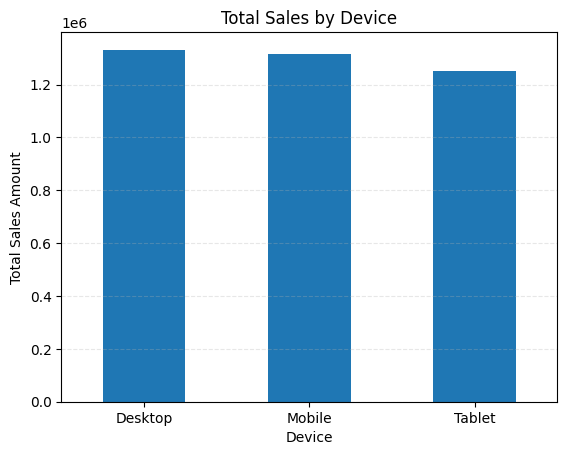

In [ ]:
sales_by_device = df.groupby("Device")["Sale_Amount"].sum()
sales_by_device.plot(kind="bar")
plt.title("Total Sales by Device")
plt.xlabel("Device")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3, linestyle="--")

plt.show()

Observation : Desktop generated the highest total sales at 1,331,958, followed by Mobile at 1,314,069 and Tablet at 1,251,341. However, Desktop also had
the highest number of advertising records. Therefore, the higher total
sales may partly be due to greater representation rather than a major
difference in individual ad performance.

11. 2. Daily Sales Trend

The line chart shows fluctuations in daily sales over the campaign period.Some dates recorded higher sales compared with others, indicating changes in campaign performance over time.

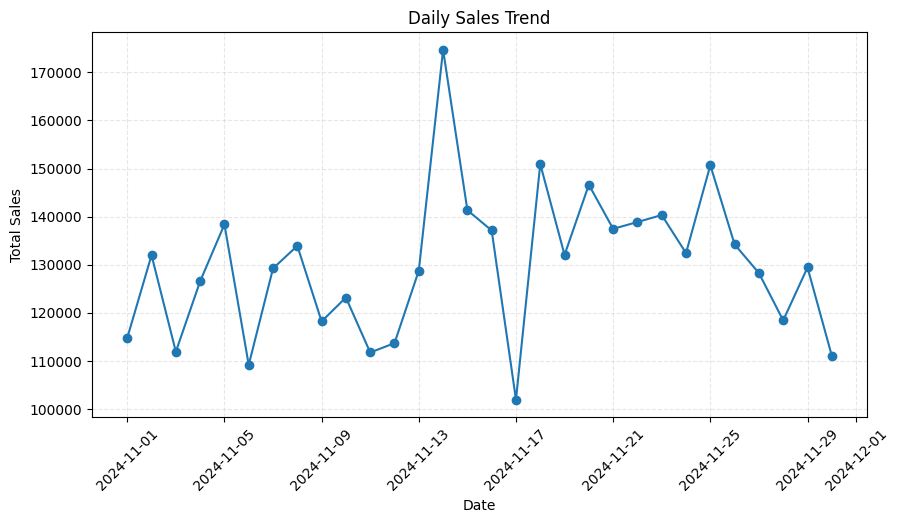

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(
    daily_sales.index,
    daily_sales.values,
    marker="o"
)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(alpha=0.3, linestyle="--")

plt.show()

Observation : Daily sales fluctuated throughout November 2024 rather than following a consistent upward or downward trend. The highest sales were recorded on 14 November at approximately 170,000+, while the lowest were recorded on 17 November at approximately 100,000+. This suggests that campaign
performance varied considerably between individual dates.

11. 3. Device Distribution

The pie chart shows the percentage distribution of advertisements across desktop, mobile and tablet devices.

autopct="%1.1f%%" displays percentages such as:

Desktop - **%
Mobile  - **%
Tablet  - **%

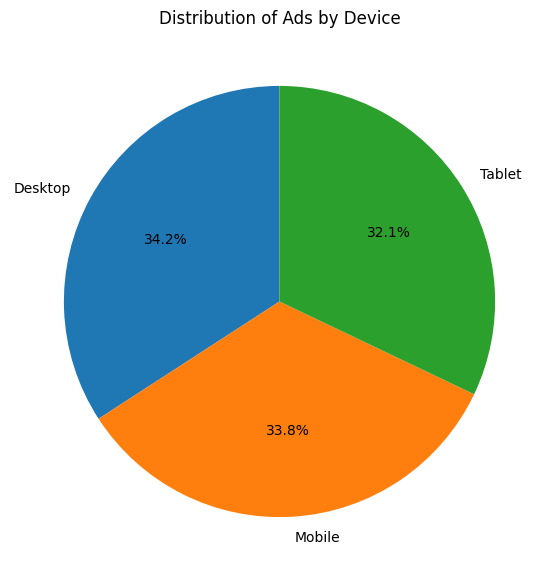

In [ ]:
device_counts = df["Device"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    device_counts.values,
    labels=device_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Ads by Device")

plt.show()

Observation : The advertisements were distributed almost equally across the three device types. Desktop represented approximately 34.2% of the records,
Mobile 33.8%, and Tablet 32.1%. This relatively balanced distribution
makes device level comparisons more meaningful.

11. 4. Sale Amount Distribution

The histogram shows the frequency distribution of sale amounts and helps identify where most sales values are concentrated.

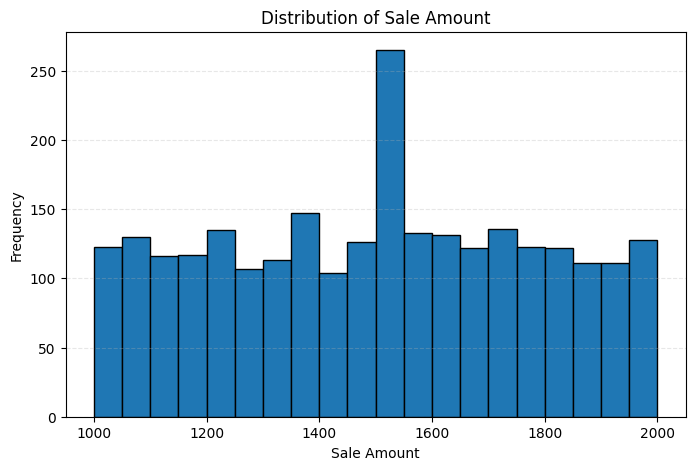

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(
    df["Sale_Amount"],
    bins=20,
    edgecolor="black"
)
plt.title("Distribution of Sale Amount")
plt.xlabel("Sale Amount")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3, linestyle="--")

plt.show()

Observation : Sale amounts ranged from 1,000 to 2,000, with a median of 1,505 and an average of approximately 1,499. The values were fairly evenly
distributed across the range, with no strong concentration at either
the lower or higher end. There is no evidence of severe skewness in the
sale amount distribution.

11. 5. Advertising Cost

The box plot displays the distribution of advertising costs and helps
identify potential unusually high or low cost values.

Note: The box represents the central portion of the data, the line inside represents the median, and points beyond the whiskers can indicate potential outliers.

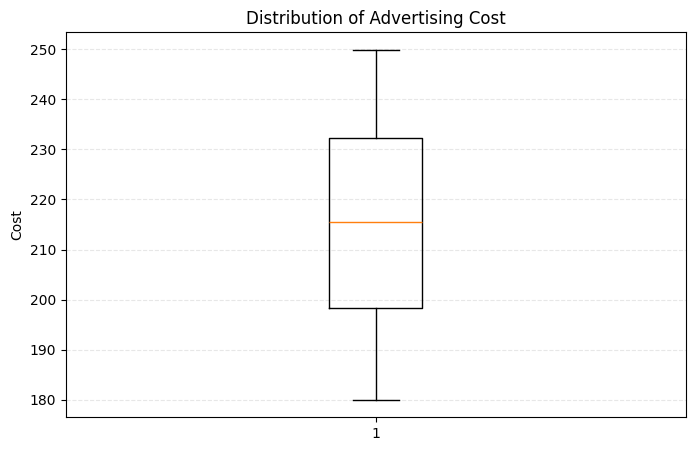

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["Cost"].dropna())
plt.title("Distribution of Advertising Cost")
plt.ylabel("Cost")
plt.grid(axis="y", alpha=0.3, linestyle="--")

plt.show()

Observation: Advertising cost ranged from approximately 180.01 to 249.89, with a
median of 215.57. The middle 50% of costs were approximately between
198.38 and 232.30. No values fell outside the box-plot outlier limits,
indicating that the Cost column does not contain significant outliers.

11. 6. Advertising Cost vs Sales

Using Scatter plot, its one of the most effective visual tools, helps you quickly determine whether the money you spend on ads actually drives revenue, and how efficiently that transformation happens.

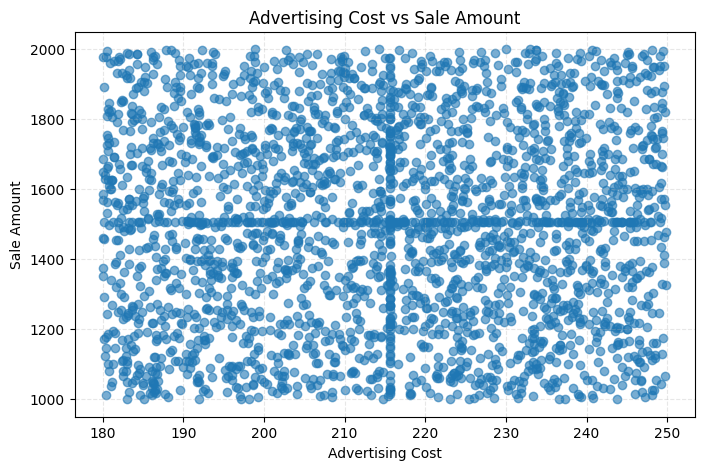

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Cost"],
    df["Sale_Amount"],
    alpha=0.6
)
plt.title("Advertising Cost vs Sale Amount")
plt.xlabel("Advertising Cost")
plt.ylabel("Sale Amount")
plt.grid(alpha=0.3, linestyle="--")

plt.show()

Observation : The scatter plot shows that sale amounts are widely distributed across all
advertising cost levels. There is no clear upward or downward pattern between
advertising cost and sale amount. The correlation is approximately 0.01,
indicating almost no linear relationship between the two variables.

Therefore, higher advertising spending did not consistently generate higher
sales in this dataset.

11. 7. Average Sales by Device

We used a Seaborn bar chart to compare the average sales across different device types. This helped us see if desktop, mobile, or tablet users spend more per transaction, making it easier to decide where to focus our ad budget.

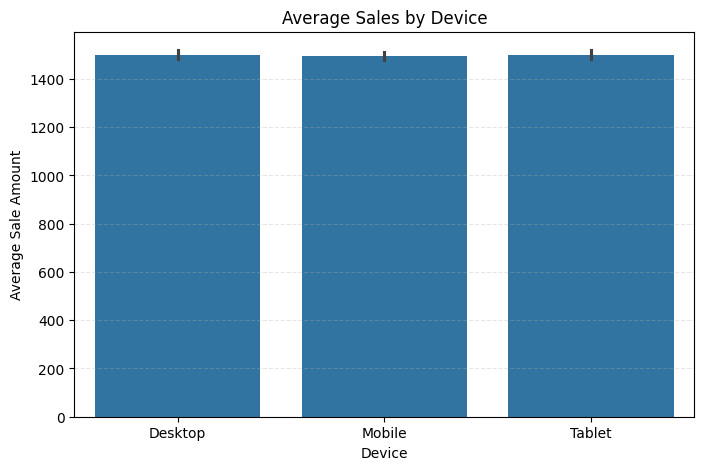

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="Device",
    y="Sale_Amount",
    estimator="mean"
)
plt.title("Average Sales by Device")
plt.xlabel("Device")
plt.ylabel("Average Sale Amount")
plt.grid(axis="y",alpha=0.3, linestyle="--")
plt.show()

Observation : Average sales were very similar across all devices. The differences are very
small, suggesting that device type had little effect on average sale
value.

11. 8. Sale Amount by Device

Here using a box plot over a standard bar chart because averages can be misleading if skewed by large sales. The box plot shows us the real story, the median sale amount, how widely performance varies per device, and whether extreme outliers are driving the numbers.

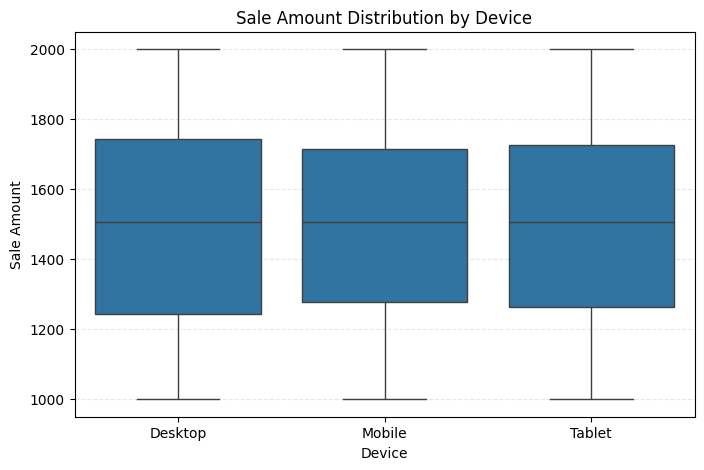

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Device",
    y="Sale_Amount"
)
plt.title("Sale Amount Distribution by Device")
plt.xlabel("Device")
plt.ylabel("Sale Amount")
plt.grid(axis="y",alpha=0.3, linestyle="--")
plt.show()

Observation : The three devices have similar median sale amounts and comparable
variation. Their boxes and ranges overlap substantially, indicating
that the sale amount distribution is broadly consistent across
Desktop, Mobile, and Tablet. No device shows a clearly superior sales
distribution.

11. 9. Clicks vs Conversions

Plotted Clicks against Conversions to see if getting more traffic actually leads to more sales. This scatter plot examines whether higher click volume is associated with more conversions. The actual relationship is determined from the plotted pattern and correlation value.

hue="Device" also allows you to distinguish desktop, mobile and tablet observations.

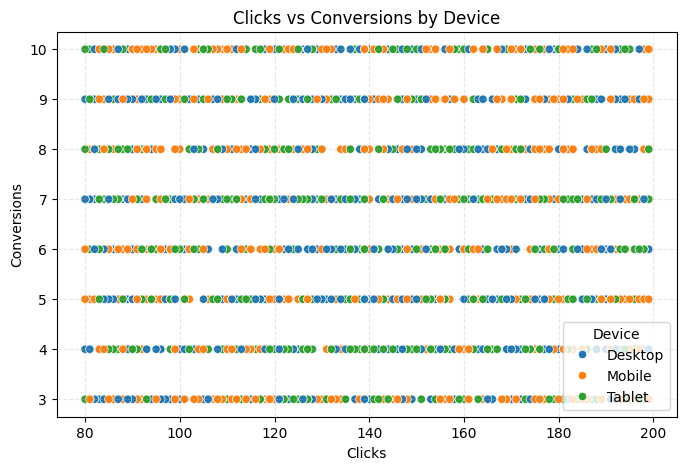

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Clicks",
    y="Conversions",
    hue="Device"
)
plt.title("Clicks vs Conversions by Device")
plt.xlabel("Clicks")
plt.ylabel("Conversions")
plt.grid(alpha=0.3, linestyle="--")
plt.show()

Observation : The points are scattered across the chart with no clear increasing
pattern. The correlation between clicks and conversions is approximately
0.01, indicating almost no linear relationship. The device groups also
overlap considerably, suggesting similar click to conversion patterns
across devices.

11. 10. Correlation Heatmap

Correlation Heatmap for last because it brings everything together. After examining individual metrics like clicks, sales, and costs separately, this heatmap lets us immediately identify which variables move together, which operate independently, and where our strongest performance drivers lie.

Correlation ranges:

-1 : Strong negative
0  : No Linear Relationship
+1 : Strong Positive

In [ ]:
# creating Correlation Columns

correlation_columns = [
    "Impressions",
    "Clicks",
    "Cost",
    "Leads",
    "Conversions",
    "Sale_Amount",
    "CTR",
    "CPC",
    "CPA",
    "ROAS"
]
correlation_matrix = df[correlation_columns].corr()

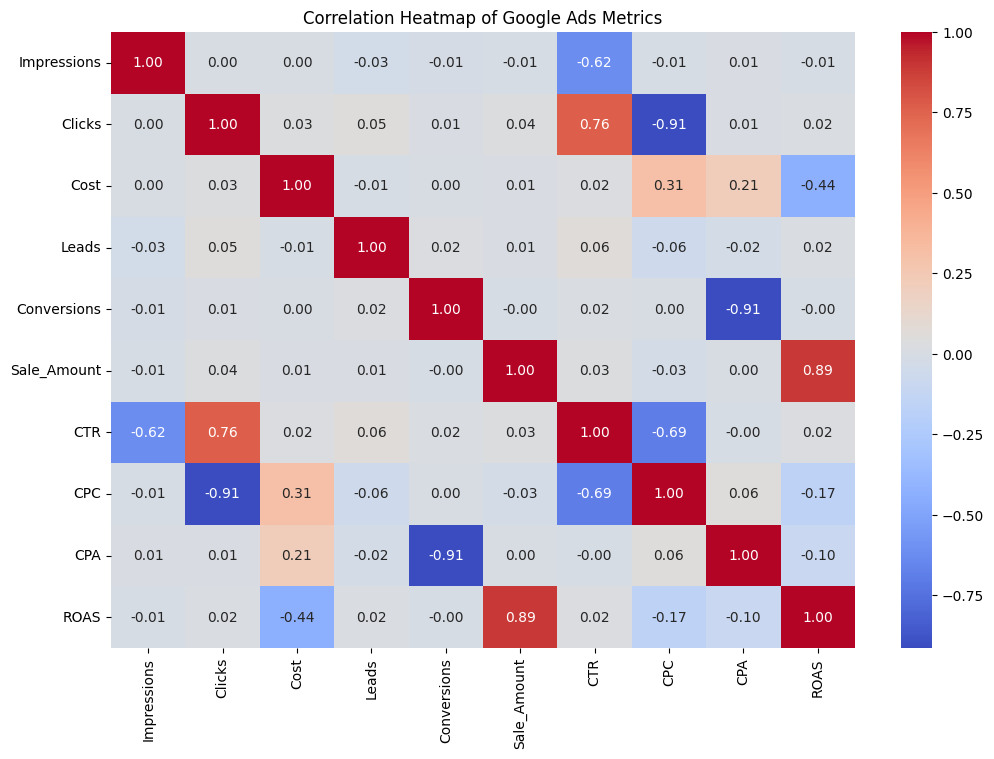

In [ ]:
# creating heatmap

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of Google Ads Metrics")
plt.show()

Observation : Most original campaign metrics have weak correlations with one another.
Clicks and CPC show a strong negative correlation because CPC is
calculated by dividing Cost by Clicks. Similarly, Conversions and CPA
have a strong negative relationship. Sale Amount and ROAS show a strong
positive correlation because Sale Amount is part of the ROAS formula.

These KPI correlations should be interpreted carefully because they are
partly mathematical relationships created by the formulas, rather than
independent business relationships.

### 12. Business insights

1) The campaign generated approximately 11.76 million impressions,
   361,293 clicks, 16,985 conversions, and 3.90 million in sales.
2) The overall CTR was approximately 3.07%, meaning that
   about three out of every 100 impressions generated a click.
3) Overall ROAS was 6.97. This means the campaign generated approximately
   6.97 in sales for every 1 spent on advertising.
4) Desktop generated the highest total sales, but it also had the highest
   number of records. Average sale values were almost identical across
   Desktop, Mobile, and Tablet.
5) Daily sales varied throughout November, with the highest sales recorded
   on 14 November and the lowest on 17 November.
6) Advertising cost and sales had almost no linear correlation. Therefore,
   simply increasing advertising expenditure did not guarantee higher sales
   in this dataset.
7) Clicks and conversions also showed almost no linear relationship,
   indicating that click volume alone may not be sufficient to predict
   conversion performance.
8) Device allocation was relatively balanced, supporting a fair comparison
   among Desktop, Mobile, and Tablet.

### 13. Conclusion

This project analyzed 2,600 Google Ads records to evaluate advertising
performance, sales generation, device level results, keyword performance,
and campaign efficiency. The dataset was cleaned by correcting inconsistent
categorical values, converting currency and date fields, and handling missing
numerical values using median imputation.

The campaign achieved an overall CTR of 3.07% and a ROAS of 6.97, indicating
that it generated approximately 6.97 in sales for every 1 spent. Desktop
produced the highest total sales, although average sale amounts were almost
equal across all devices. The analysis also found that higher advertising
cost did not consistently result in higher individual sales.

Based on these findings, campaign decisions should consider ROAS, CPA,
conversion quality, and keyword performance together rather than relying
only on total clicks or advertising expenditure.

### Project Limitations



*   The dataset covers only one campaign, one location, and one month.
*   Missing numerical values were estimated using median imputation.
*   The analysis identifies associations but does not prove causation.
*   The findings may not represent other campaigns, locations, or periods.



